In [1]:
# ================================
# 1. IMPORT REQUIRED LIBRARIES
# ================================

# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Clustering models
from sklearn.cluster import KMeans, AgglomerativeClustering

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

# PCA for clustering visualization
from sklearn.decomposition import PCA

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("water_dataX.csv", encoding="latin1")

print("Dataset loaded successfully")
print("Rows, Columns:", df.shape)
df.head()

Dataset loaded successfully
Rows, Columns: (1991, 12)


,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014


In [3]:
# ================================
# 3. DATASET OVERVIEW
# ================================

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape of dataset: (1991, 12)

Column names:
['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (µmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   STATION CODE                      1991 non-null   object
 1   LOCATIONS                         1991 non-null   object
 2   STATE                             1991 non-null   object
 3   Temp                              1991 non-null   object
 4   D.O. (mg/l)                       1991 non-null   object
 5   PH                                1991 non-null   object
 6   CONDUCTIVITY (µmhos/cm)           1991 non-null   object
 7   B.O.D. (mg/l)                     1991 non-n

In [4]:
print("Rows, Columns:", df.shape)

Rows, Columns: (1991, 12)


In [5]:
# ================================
# CHECK MISSING VALUES + DUPLICATES
# ================================

print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 STATION CODE                        0
LOCATIONS                           0
STATE                               0
Temp                                0
D.O. (mg/l)                         0
PH                                  0
CONDUCTIVITY (µmhos/cm)             0
B.O.D. (mg/l)                       0
NITRATENAN N+ NITRITENANN (mg/l)    0
FECAL COLIFORM (MPN/100ml)          0
TOTAL COLIFORM (MPN/100ml)Mean      0
year                                0
dtype: int64

Duplicates: 1


In [6]:
df.head()

,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014


In [7]:
# ================================
# CONVERT WATER COLUMNS TO NUMERIC
# ================================

# list of numerical water quality columns
num_cols = [
    'Temp',
    'D.O. (mg/l)',
    'PH',
    'CONDUCTIVITY (µmhos/cm)',
    'B.O.D. (mg/l)',
    'NITRATENAN N+ NITRITENANN (mg/l)',
    'FECAL COLIFORM (MPN/100ml)',
    'TOTAL COLIFORM (MPN/100ml)Mean'
]

# convert object columns into numeric
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# check updated datatypes
print(df[num_cols].dtypes)

Temp                                float64
D.O. (mg/l)                         float64
PH                                  float64
CONDUCTIVITY (µmhos/cm)             float64
B.O.D. (mg/l)                       float64
NITRATENAN N+ NITRITENANN (mg/l)    float64
FECAL COLIFORM (MPN/100ml)          float64
TOTAL COLIFORM (MPN/100ml)Mean      float64
dtype: object


In [8]:
# ================================
# CHECK MISSING VALUES + DUPLICATES
# ================================

print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 STATION CODE                          0
LOCATIONS                             0
STATE                                 0
Temp                                 92
D.O. (mg/l)                          31
PH                                    8
CONDUCTIVITY (µmhos/cm)              25
B.O.D. (mg/l)                        43
NITRATENAN N+ NITRITENANN (mg/l)    225
FECAL COLIFORM (MPN/100ml)          316
TOTAL COLIFORM (MPN/100ml)Mean      132
year                                  0
dtype: int64

Duplicates: 1


In [9]:
# ================================
# HANDLE MISSING VALUES (MEDIAN)
# ================================

# check missing values
print("Before handling:\n", df[num_cols].isnull().sum())

# fill with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# verify
print("\nAfter handling:\n", df[num_cols].isnull().sum())

Before handling:
 Temp                                 92
D.O. (mg/l)                          31
PH                                    8
CONDUCTIVITY (µmhos/cm)              25
B.O.D. (mg/l)                        43
NITRATENAN N+ NITRITENANN (mg/l)    225
FECAL COLIFORM (MPN/100ml)          316
TOTAL COLIFORM (MPN/100ml)Mean      132
dtype: int64

After handling:
 Temp                                0
D.O. (mg/l)                         0
PH                                  0
CONDUCTIVITY (µmhos/cm)             0
B.O.D. (mg/l)                       0
NITRATENAN N+ NITRITENANN (mg/l)    0
FECAL COLIFORM (MPN/100ml)          0
TOTAL COLIFORM (MPN/100ml)Mean      0
dtype: int64


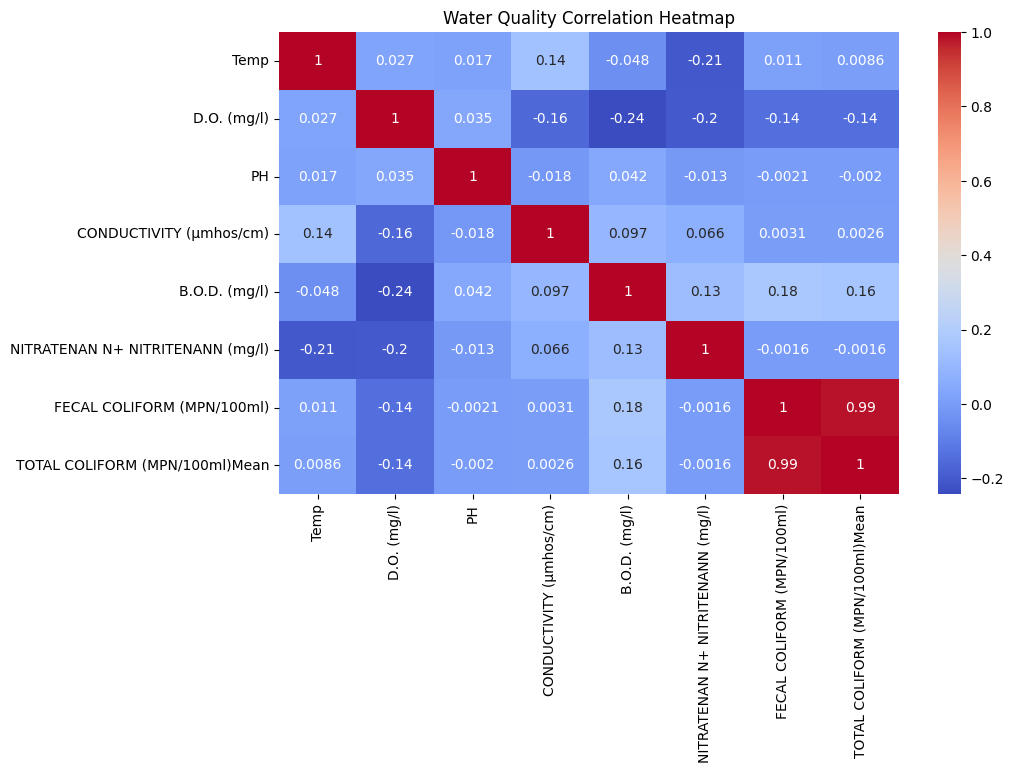

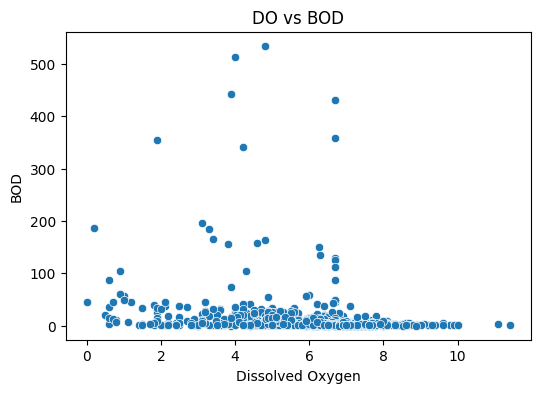

In [10]:
# ================================
# CORRELATION HEATMAP
# ================================

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Water Quality Correlation Heatmap")
plt.show()

# ----------------
# Scatter Plot (DO vs BOD)
# ----------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['D.O. (mg/l)'],
    y=df['B.O.D. (mg/l)']
)
plt.title("DO vs BOD")
plt.xlabel("Dissolved Oxygen")
plt.ylabel("BOD")
plt.show()


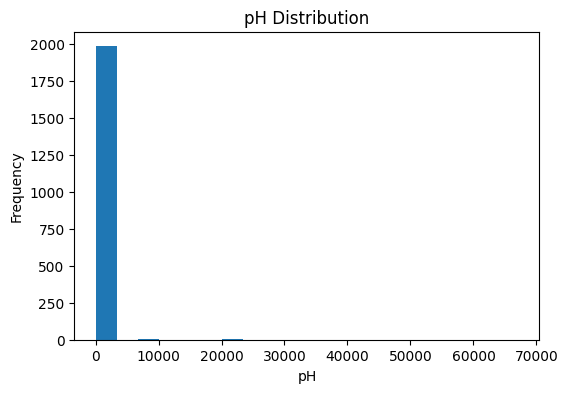

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df['PH'].dropna(), bins=20)
plt.title("pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

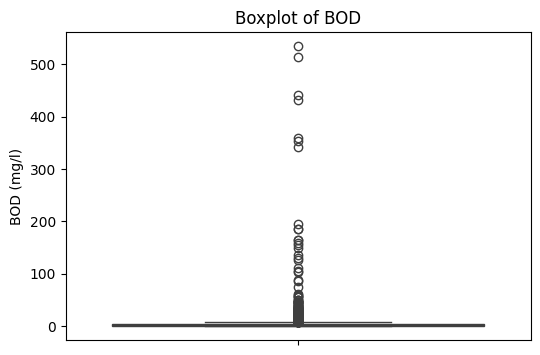

In [11]:



# ----------------
# Boxplot (BOD)
# ----------------
plt.figure(figsize=(6,4))
sns.boxplot(y=df['B.O.D. (mg/l)'])
plt.title("Boxplot of BOD")
plt.ylabel("BOD (mg/l)")
plt.show()


In [13]:
# ================================
# BINARY SAFE VS UNSAFE TARGET
# ================================

def classify_binary_risk(row):
    if (
        row['PH'] < 6.5 or row['PH'] > 8.5 or
        row['D.O. (mg/l)'] < 6 or
        row['B.O.D. (mg/l)'] > 3 or
        row['FECAL COLIFORM (MPN/100ml)'] > 500
    ):
        return 1   # Unsafe
    else:
        return 0   # Safe

df['risk_level'] = df.apply(classify_binary_risk, axis=1)

print(df['risk_level'].value_counts())

risk_level
1    1242
0     749
Name: count, dtype: int64


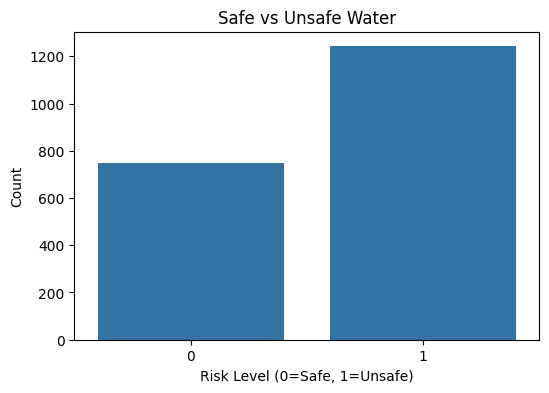

In [15]:

if 'risk_level' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='risk_level', data=df)
    plt.title("Safe vs Unsafe Water")
    plt.xlabel("Risk Level (0=Safe, 1=Unsafe)")
    plt.ylabel("Count")
    plt.show()

In [17]:
# ================================
# FEATURE SELECTION
# ================================

features = [
    'Temp',
    'D.O. (mg/l)',
    'PH',
    'CONDUCTIVITY (µmhos/cm)',
    'B.O.D. (mg/l)',
    'NITRATENAN N+ NITRITENANN (mg/l)',
    'FECAL COLIFORM (MPN/100ml)',
    'TOTAL COLIFORM (MPN/100ml)Mean'
]

X = df[features]
y = df['risk_level']

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (1991, 8)
Target: (1991,)


In [18]:
# ================================
# TRAIN TEST SPLIT
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# ================================
# SCALING
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

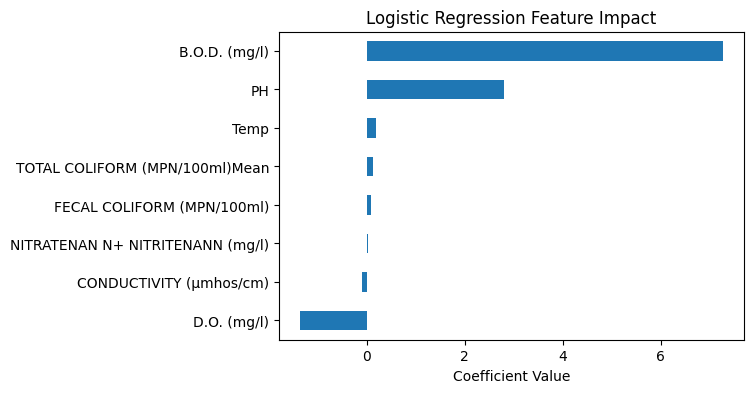

Logistic Regression Report

              precision    recall  f1-score   support

           0       0.62      0.54      0.58       150
           1       0.74      0.80      0.77       249

    accuracy                           0.70       399
   macro avg       0.68      0.67      0.67       399
weighted avg       0.70      0.70      0.70       399



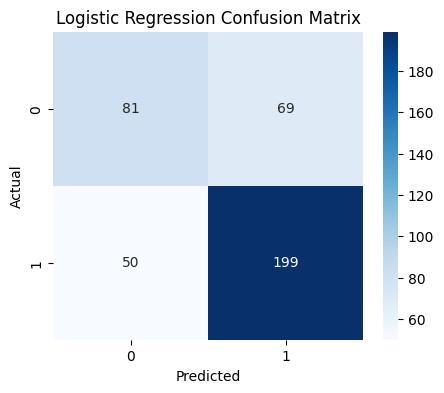

In [20]:
# ================================
# LOGISTIC REGRESSION
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# train model (scaled data)
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# predict
y_pred_lr = lr.predict(X_test_scaled)

# ----------------
# GRAPH: Coefficients
# ----------------
coeff = pd.Series(lr.coef_[0], index=X.columns)

plt.figure(figsize=(6,4))
coeff.sort_values().plot(kind='barh')
plt.title("Logistic Regression Feature Impact")
plt.xlabel("Coefficient Value")
plt.show()

# ----------------
# CONFUSION MATRIX
# ----------------
print("Logistic Regression Report\n")
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

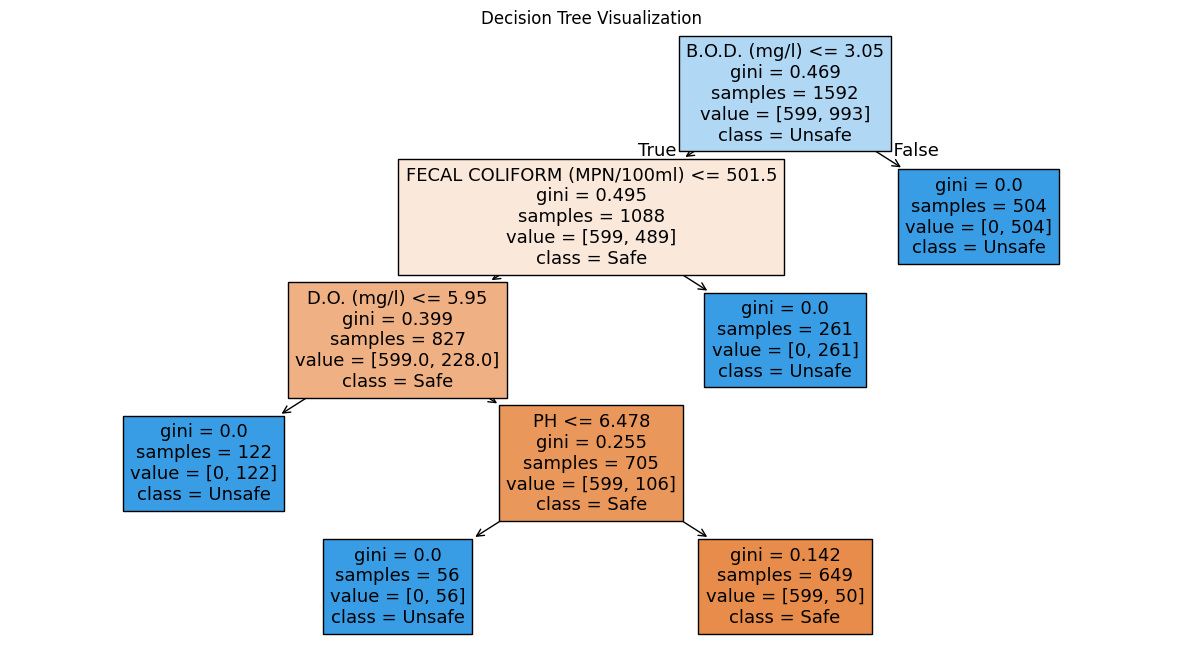

Decision Tree Report

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       150
           1       1.00      0.93      0.96       249

    accuracy                           0.95       399
   macro avg       0.95      0.96      0.95       399
weighted avg       0.96      0.95      0.96       399



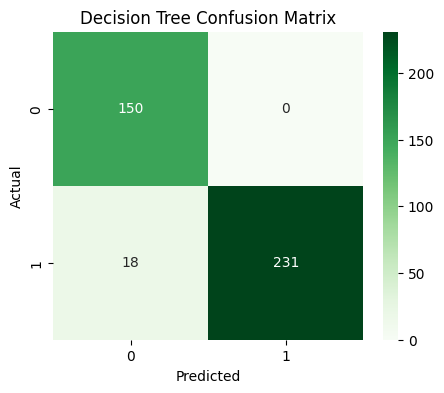

In [21]:
# ================================
# DECISION TREE
# ================================

from sklearn.tree import DecisionTreeClassifier, plot_tree

# train model (non-scaled data)
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# predict
y_pred_dt = dt.predict(X_test)

# ----------------
# GRAPH: Decision Tree
# ----------------
plt.figure(figsize=(15,8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=["Safe", "Unsafe"],
          filled=True)
plt.title("Decision Tree Visualization")
plt.show()

# ----------------
# CONFUSION MATRIX
# ----------------
print("Decision Tree Report\n")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True,
            fmt='d',
            cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# ================================
# FEATURE SCALING FOR CLUSTERING
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# ================================
# KMEANS CLUSTERING
# ================================

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print("KMeans Cluster Counts")
print(df['KMeans_Cluster'].value_counts())

KMeans Cluster Counts
KMeans_Cluster
0    1671
1     317
2       3
Name: count, dtype: int64


In [24]:
# ================================
# AGGLOMERATIVE CLUSTERING
# ================================

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)

df['Agglo_Cluster'] = agg.fit_predict(X_scaled)

print("Agglomerative Cluster Counts")
print(df['Agglo_Cluster'].value_counts())

Agglomerative Cluster Counts
Agglo_Cluster
0    1976
2      12
1       3
Name: count, dtype: int64


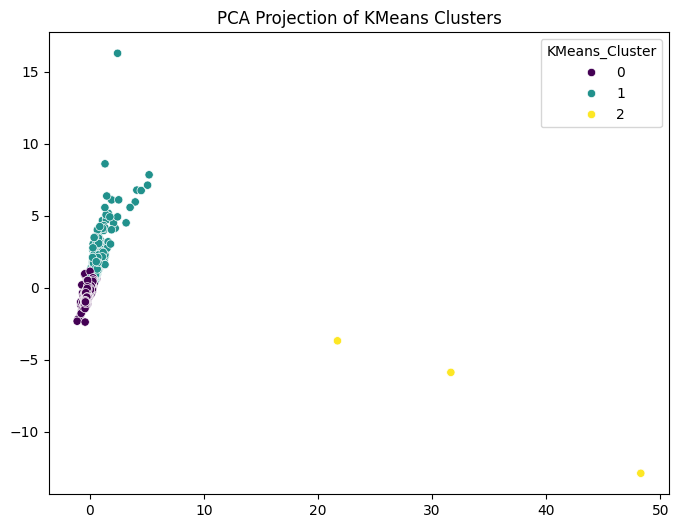

In [25]:
# ================================
# PCA VISUALIZATION FOR KMEANS
# ================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)
plt.title("PCA Projection of KMeans Clusters")
plt.show()

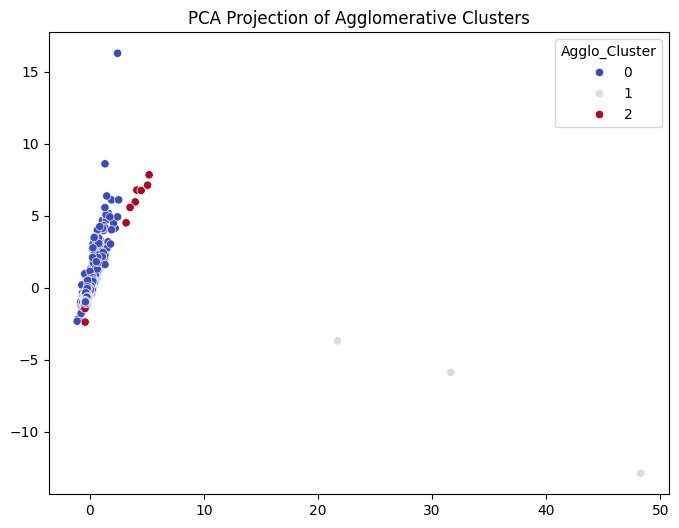

In [26]:
# ================================
# PCA VISUALIZATION FOR AGGLO
# ================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Agglo_Cluster'],
    palette='coolwarm'
)
plt.title("PCA Projection of Agglomerative Clusters")
plt.show()

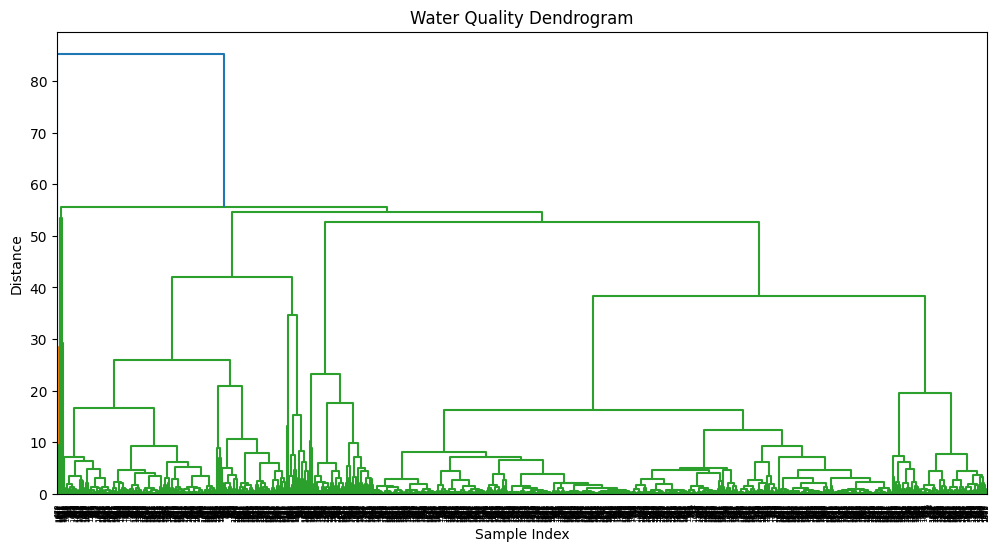

In [28]:
# ================================
# DENDROGRAM
# ================================

from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Water Quality Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

                 Model  Accuracy
0  Logistic Regression  0.701754
1        Decision Tree  0.954887


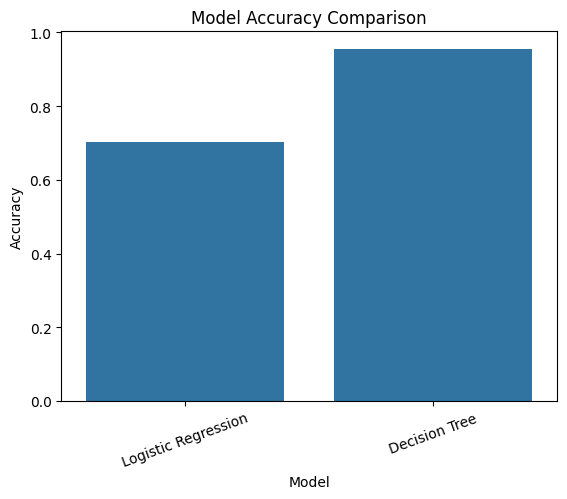

In [30]:
# ================================
# MODEL COMPARISON
# ================================

from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)        
    ]
})

print(results)
# ================================
# ACCURACY VISUALIZATION
# ================================

sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

In [31]:
import os
print(os.getcwd())

C:\Users\shrey\dspl
